# Kenya Maternal & Child Health Analysis
## A Four-Part County-Level Data Series | KDHS 2022

**Author:** Felix Beru | Data Analyst | Nairobi, Kenya  
**Data Source:** Kenya Demographic and Health Survey (KDHS) 2022  
**Tools:** Python, Pandas, Matplotlib, Google Colab

---

### About This Project
This notebook presents a four-part analysis of maternal and child health
indicators across all 47 Kenyan counties using data from the Kenya
Demographic and Health Survey (KDHS) 2022, published by the Kenya
National Bureau of Statistics (KNBS).

The analysis goes beyond national averages to reveal county-level disparities
that are hidden in headline figures — showing where Kenya's maternal health
system is working and where women and children are being left behind.

### Projects in this Series
1. Skilled Antenatal Care Coverage by County
2. Under-5 Mortality Rate by County
3. ANC Quality — Beyond the 97% Coverage Figure
4. Health Facility Delivery Rate by County

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import io
from google.colab import files

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


---
## Project 1 — Skilled Antenatal Care Coverage by County

Kenya's national ANC coverage stands at 97.1% — but does that number
tell the full story? This project examines skilled ANC coverage across
all 47 counties to reveal the regional divide behind the headline figure.

**Key Question:** Which counties are leaving women without skilled
antenatal care?

In [18]:
# Upload ANC coverage CSV
print("Please upload: Antenatal care by county.csv")
uploaded = files.upload()
df_anc = pd.read_csv(io.BytesIO(list(uploaded.values())[0]), encoding='latin1')
df_anc.columns = df_anc.columns.str.strip()
print("✅ ANC Coverage data loaded")
print(df_anc.head())

Please upload: Antenatal care by county.csv


Saving Antenatal care by county.csv to Antenatal care by county (4).csv
✅ ANC Coverage data loaded
   Sn      County  Doctor  Nurse/midwife/clinical officer  \
0   1     Mombasa    68.5                            30.9   
1   2       Kwale    26.9                            72.4   
2   3      Kilifi    34.0                            65.3   
3   4  Tana River     5.6                            89.7   
4   5        Lamu    38.3                            59.6   

   Community health worker/fieldworker  Traditional birth attendant  No ANC  \
0                                  0.0                          0.0     0.6   
1                                  0.0                          0.0     0.7   
2                                  0.0                          0.0     0.7   
3                                  0.6                          0.7     3.4   
4                                  0.0                          0.0     2.1   

   Total  Percentage receiving antenatal care from a skille

/tmp/ipykernel_3455/1180857237.py:41: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3455/1180857237.py:42: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  plt.savefig('/content/kenya_anc_coverage_final.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


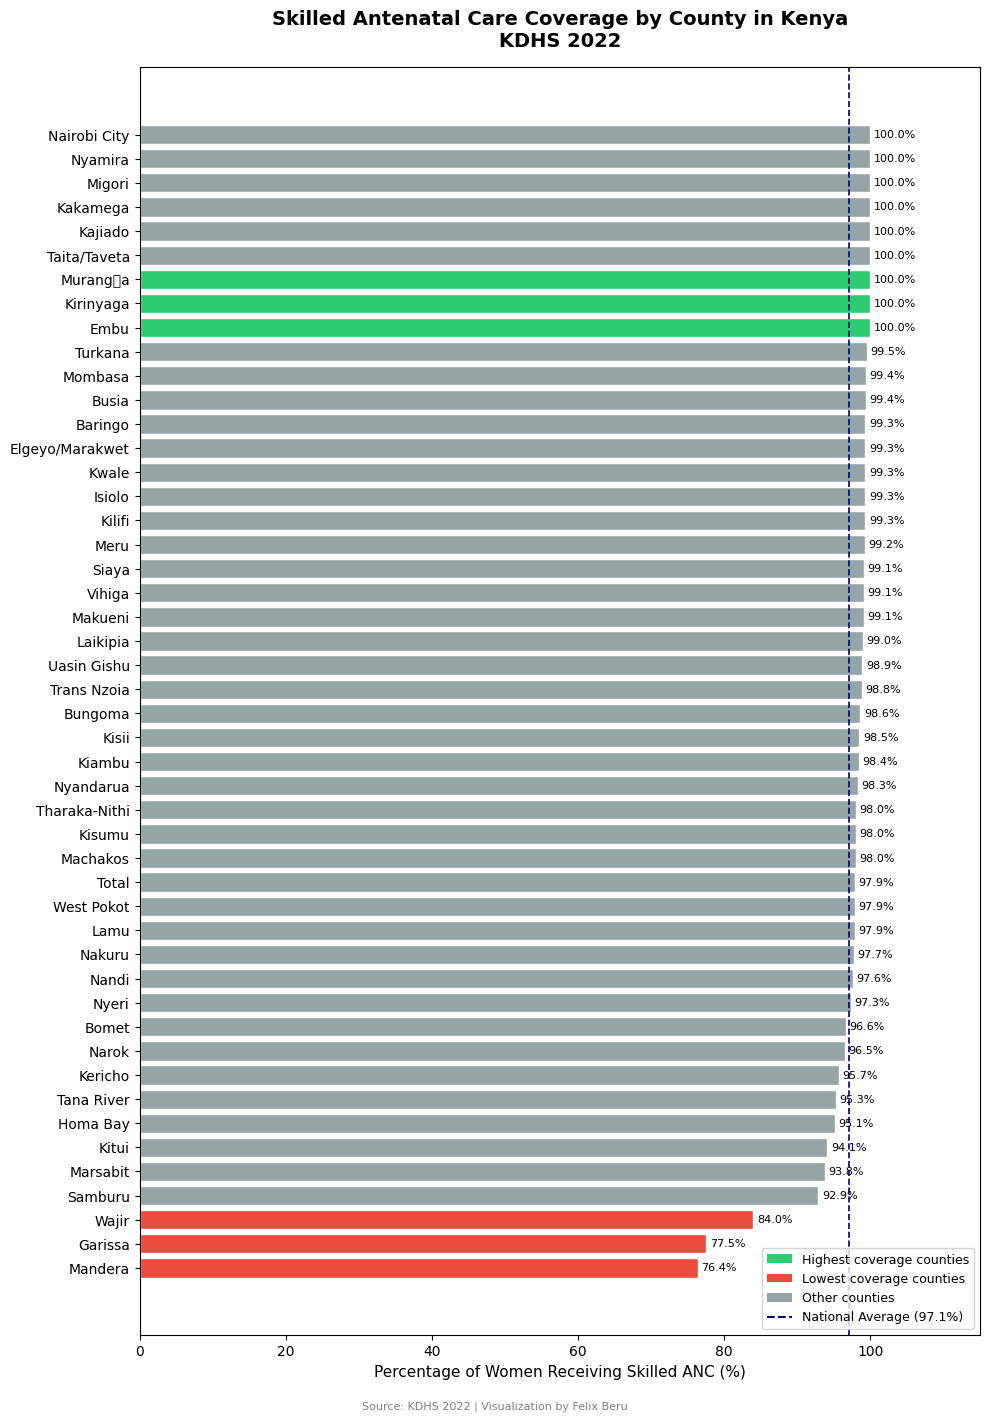

National Average: 97.1%
Highest: ['Embu', 'Kirinyaga', 'Murang\x92a']
Lowest: ['Mandera', 'Garissa', 'Wajir']


In [19]:
anc_col = 'Percentage receiving antenatal care from a skilled provider'

df_anc_sorted = df_anc.sort_values(anc_col, ascending=True)
national_avg_anc = df_anc[anc_col].mean()

high = df_anc_sorted.nlargest(3, anc_col)['County'].tolist()
low = df_anc_sorted.nsmallest(3, anc_col)['County'].tolist()

def get_color_anc(county):
    if county in high: return '#2ecc71'
    elif county in low: return '#e74c3c'
    else: return '#95a5a6'

colors = [get_color_anc(c) for c in df_anc_sorted['County']]

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(df_anc_sorted['County'], df_anc_sorted[anc_col],
        color=colors, edgecolor='white')

for i, val in enumerate(df_anc_sorted[anc_col]):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=8)

ax.axvline(x=national_avg_anc, color='navy', linestyle='--', linewidth=1.2)

legend_elements = [
    mpatches.Patch(facecolor='#2ecc71', label='Highest coverage counties'),
    mpatches.Patch(facecolor='#e74c3c', label='Lowest coverage counties'),
    mpatches.Patch(facecolor='#95a5a6', label='Other counties'),
    plt.Line2D([0], [0], color='navy', linestyle='--',
               label=f'National Average ({national_avg_anc:.1f}%)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_title('Skilled Antenatal Care Coverage by County in Kenya\nKDHS 2022',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Percentage of Women Receiving Skilled ANC (%)', fontsize=11)
ax.set_xlim(0, 115)
fig.text(0.5, -0.01,
         'Source: KDHS 2022 | Visualization by Felix Beru',
         ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('/content/kenya_anc_coverage_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"National Average: {national_avg_anc:.1f}%")
print(f"Highest: {high}")
print(f"Lowest: {low}")

### Project 1 — Findings
- **National Average:** 97.1% skilled ANC coverage
- **Highest coverage:** Nairobi City, Nyamira and Migori
- **Lowest coverage:** Mandera, Garissa and Wajir
- Counties in North Eastern Kenya fall significantly below the national
  average, indicating that geography and infrastructure remain critical
  barriers for women accessing maternal care


## Project 2 — Under-5 Mortality Rate by County

Child survival in Kenya varies dramatically by county. This project
examines under-5 mortality rates across all 47 counties to understand
where children are most at risk — and why the patterns don't always
follow what we'd expect.

**Key Question:** Which counties have the highest under-5 mortality
and what drives those rates?

In [20]:
print("Please upload: Under-5 mortality by county.csv")
uploaded = files.upload()
df_mort = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
df_mort.columns = df_mort.columns.str.strip()
print("✅ Mortality data loaded")
print(df_mort.head())

Please upload: Under-5 mortality by county.csv


Saving under5_mortality_by_county.csv to under5_mortality_by_county (1).csv
✅ Mortality data loaded
       County  Under-5 mortality (5q0)
0     Mombasa                       50
1       Kwale                       30
2      Kilifi                       40
3  Tana River                       45
4        Lamu                       50


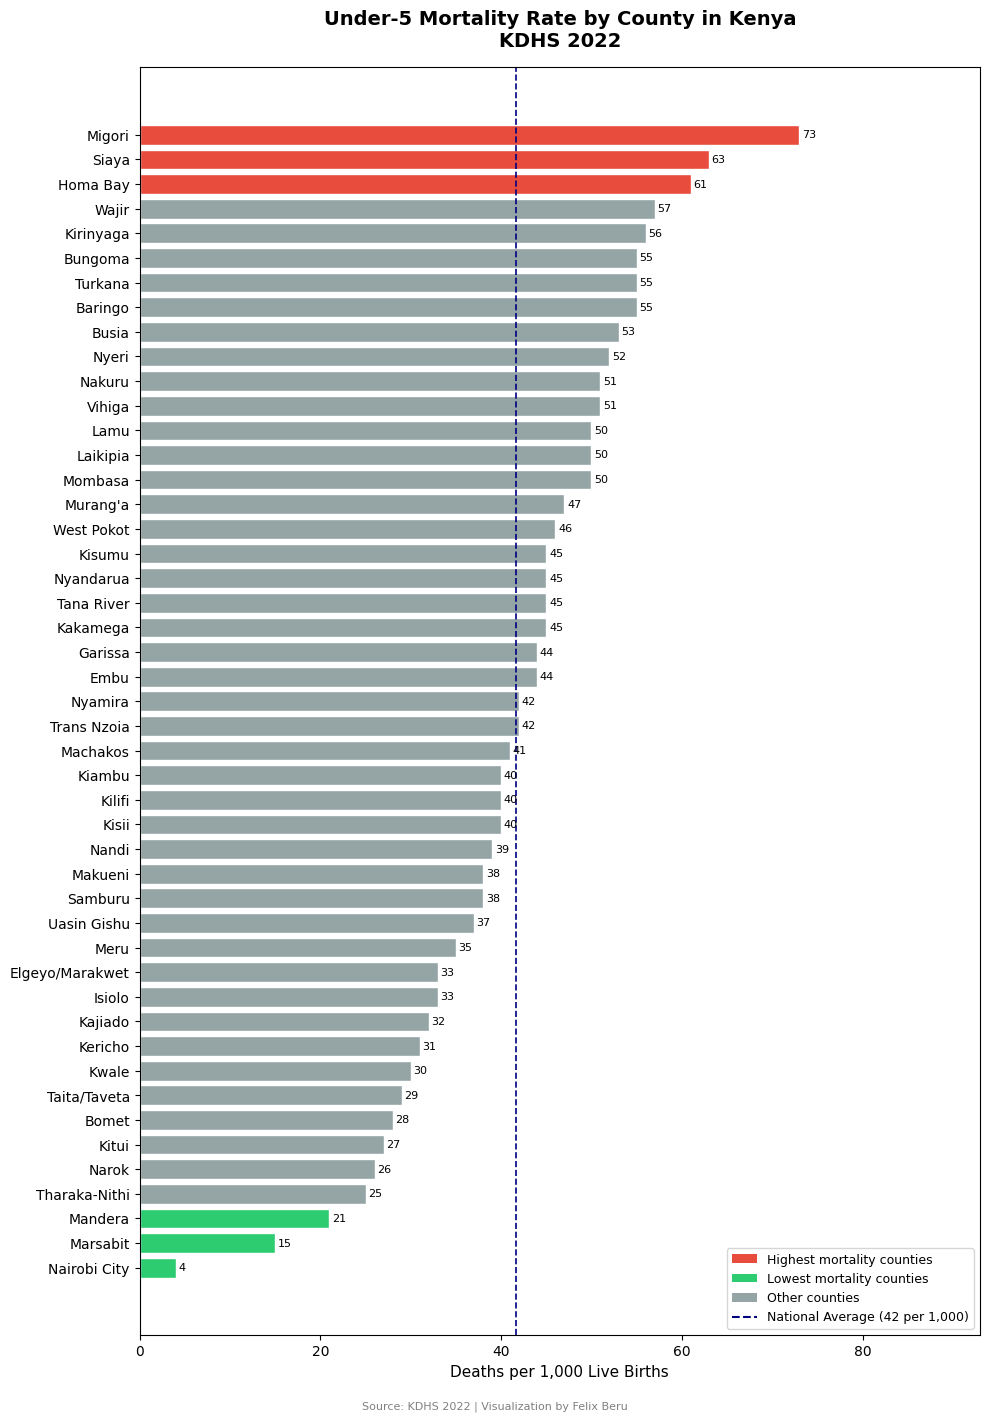

National Average: 42 deaths per 1,000 live births
Highest mortality: ['Migori', 'Siaya', 'Homa Bay']
Lowest mortality: ['Nairobi City', 'Marsabit', 'Mandera']


In [21]:
u5_col = [col for col in df_mort.columns if '5q0' in col][0]

df_mort_sorted = df_mort.sort_values(u5_col, ascending=True)
national_avg_mort = df_mort[u5_col].mean()

high_mort = df_mort_sorted.nlargest(3, u5_col)['County'].tolist()
low_mort = df_mort_sorted.nsmallest(3, u5_col)['County'].tolist()

def get_color_mort(county):
    if county in high_mort: return '#e74c3c'
    elif county in low_mort: return '#2ecc71'
    else: return '#95a5a6'

colors = [get_color_mort(c) for c in df_mort_sorted['County']]

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(df_mort_sorted['County'], df_mort_sorted[u5_col],
        color=colors, edgecolor='white')

for i, val in enumerate(df_mort_sorted[u5_col]):
    ax.text(val + 0.3, i, f'{val:.0f}', va='center', fontsize=8)

ax.axvline(x=national_avg_mort, color='navy', linestyle='--', linewidth=1.2)

legend_elements = [
    mpatches.Patch(facecolor='#e74c3c', label='Highest mortality counties'),
    mpatches.Patch(facecolor='#2ecc71', label='Lowest mortality counties'),
    mpatches.Patch(facecolor='#95a5a6', label='Other counties'),
    plt.Line2D([0], [0], color='navy', linestyle='--',
               label=f'National Average ({national_avg_mort:.0f} per 1,000)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_title('Under-5 Mortality Rate by County in Kenya\nKDHS 2022',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Deaths per 1,000 Live Births', fontsize=11)
ax.set_xlim(0, df_mort_sorted[u5_col].max() + 20)
fig.text(0.5, -0.01,
         'Source: KDHS 2022 | Visualization by Felix Beru',
         ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('/content/kenya_under5_mortality.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"National Average: {national_avg_mort:.0f} deaths per 1,000 live births")
print(f"Highest mortality: {high_mort}")
print(f"Lowest mortality: {low_mort}")

### Project 2 — Findings
- **National Average:** 42 deaths per 1,000 live births
- **Highest mortality:** Migori, Siaya and Homa Bay
- **Lowest mortality:** Nairobi City, Mandera and Marsabit
- The Nyanza region shows elevated mortality likely driven by malaria
  and HIV burden — despite having better infrastructure than
  North Eastern counties
- Counties like Mandera have low ANC coverage but relatively low
  under-5 mortality — showing that child survival is shaped by disease
  ecology, not just poverty or remoteness

---
## Project 3 — ANC Quality: Beyond the 97% Coverage Figure

Following feedback from health professionals on LinkedIn, this project
goes deeper than attendance numbers to examine the quality of ANC —
how many visits women completed, whether they started in the first
trimester, and how many received no care at all.

**Key Question:** Does Kenya's 97.1% ANC coverage figure tell the
truth about maternal care quality?

In [22]:
print("Please upload: anc_quality_by_county.csv")
uploaded = files.upload()
df_qual = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
df_qual.columns = df_qual.columns.str.strip()
print("✅ ANC Quality data loaded")
print(df_qual.head())

Please upload: anc_quality_by_county.csv


Saving anc_quality_by_county.csv to anc_quality_by_county (2).csv
✅ ANC Quality data loaded
       County  ANC_4plus_visits  No_ANC  First_visit_under4months
0     Mombasa              65.3     0.6                      21.5
1       Kwale              48.5     0.7                      24.2
2      Kilifi              77.3     0.7                      30.9
3  Tana River              61.2     3.4                      17.1
4        Lamu              47.1     2.1                      21.9


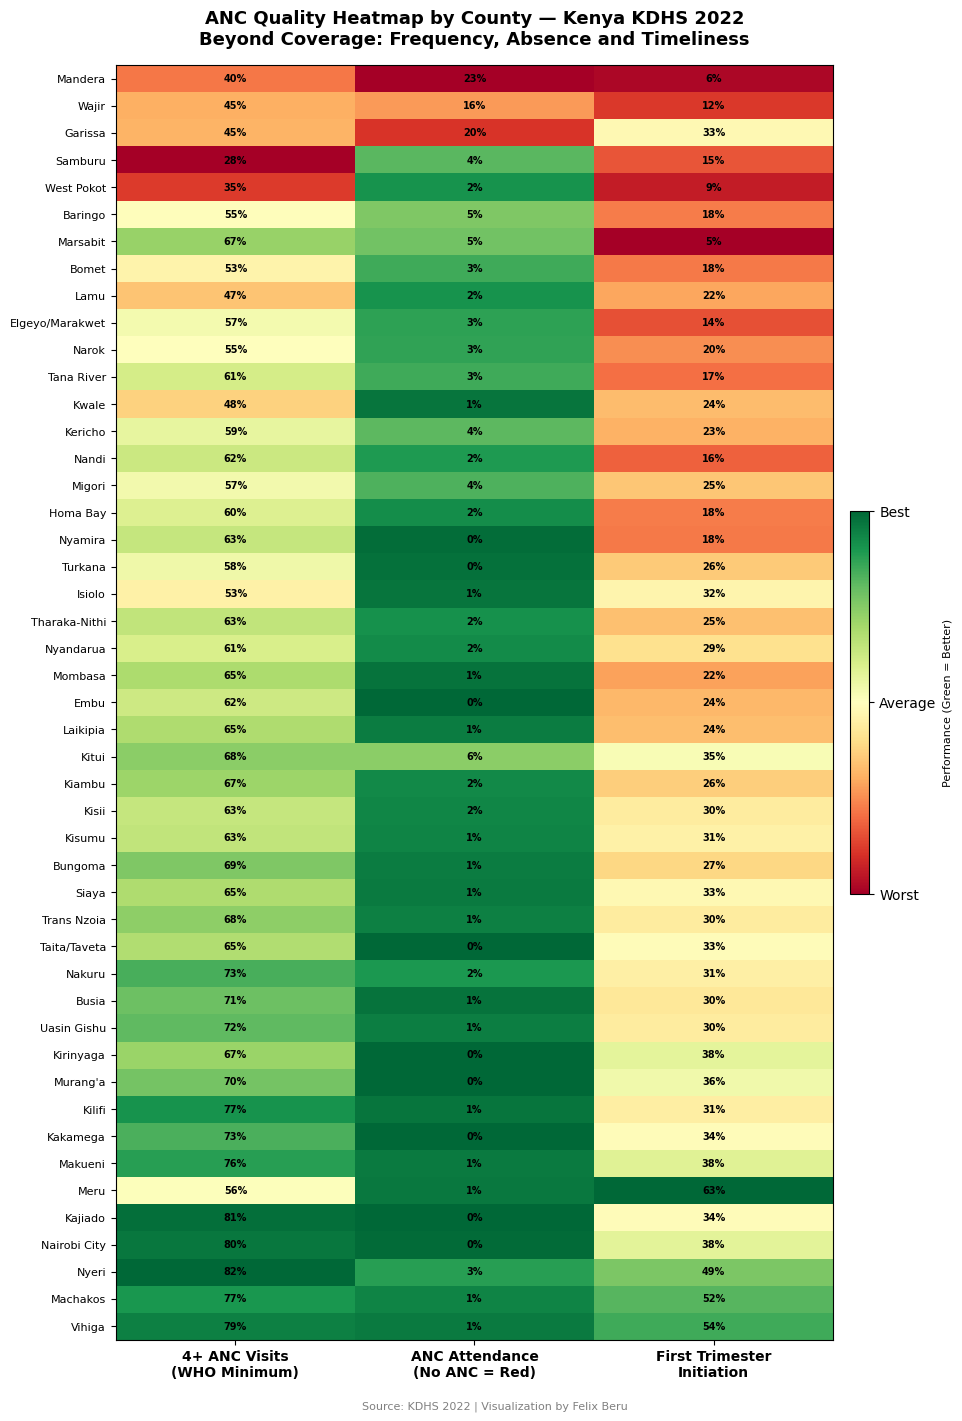

National Avg 4+ visits: 62.3%
National Avg No ANC: 2.9%
National Avg First trimester: 27.6%


In [23]:
df_heat = df_qual.copy()

df_heat['ANC_4plus_norm'] = (df_qual['ANC_4plus_visits'] - df_qual['ANC_4plus_visits'].min()) / (df_qual['ANC_4plus_visits'].max() - df_qual['ANC_4plus_visits'].min())
df_heat['First_visit_norm'] = (df_qual['First_visit_under4months'] - df_qual['First_visit_under4months'].min()) / (df_qual['First_visit_under4months'].max() - df_qual['First_visit_under4months'].min())
df_heat['No_ANC_norm'] = 1 - (df_qual['No_ANC'] - df_qual['No_ANC'].min()) / (df_qual['No_ANC'].max() - df_qual['No_ANC'].min())

df_heat['overall'] = (df_heat['ANC_4plus_norm'] + df_heat['First_visit_norm'] + df_heat['No_ANC_norm']) / 3
df_heat = df_heat.sort_values('overall', ascending=True)

matrix = df_heat[['ANC_4plus_norm', 'No_ANC_norm', 'First_visit_norm']].values

fig, ax = plt.subplots(figsize=(10, 14))
im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels([
    '4+ ANC Visits\n(WHO Minimum)',
    'ANC Attendance\n(No ANC = Red)',
    'First Trimester\nInitiation'
], fontsize=10, fontweight='bold')

ax.set_yticks(range(len(df_heat)))
ax.set_yticklabels(df_heat['County'], fontsize=8)

col_keys = ['ANC_4plus_visits', 'No_ANC', 'First_visit_under4months']
for i in range(len(df_heat)):
    for j, key in enumerate(col_keys):
        val = df_heat.iloc[i][key]
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                fontsize=7, color='black', fontweight='bold')

cbar = plt.colorbar(im, ax=ax, shrink=0.3, pad=0.02)
cbar.set_label('Performance (Green = Better)', fontsize=8)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Worst', 'Average', 'Best'])

ax.set_title('ANC Quality Heatmap by County — Kenya KDHS 2022\n'
             'Beyond Coverage: Frequency, Absence and Timeliness',
             fontsize=13, fontweight='bold', pad=15)
fig.text(0.5, -0.01,
         'Source: KDHS 2022 | Visualization by Felix Beru',
         ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('/content/kenya_anc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"National Avg 4+ visits: {df_qual['ANC_4plus_visits'].mean():.1f}%")
print(f"National Avg No ANC: {df_qual['No_ANC'].mean():.1f}%")
print(f"National Avg First trimester: {df_qual['First_visit_under4months'].mean():.1f}%")

### Project 3 — Findings
- Only **62.3%** of women nationally complete WHO recommended 4+ ANC visits
- Only **27.6%** begin care in the first trimester
- **Mandera, Garissa and Wajir** are red across all three quality
  indicators — consistently worst performing
- **Meru, Vihiga and Machakos** show strong first trimester initiation
- Kenya's challenge is no longer getting women to attend ANC — it's
  getting them there early enough and often enough to matter


## Project 4 — Health Facility Delivery Rate by County

Where a woman delivers her baby is one of the strongest predictors of
maternal survival. This project examines health facility delivery rates
across all 47 counties — and introduces a diverging chart to show which
counties fall above and below the national average.

**Key Question:** How many Kenyan women are still delivering outside
a health facility — and where are they?

In [24]:
print("Please upload: health_facility_delivery_by_county.csv")
uploaded = files.upload()
df_del = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
df_del.columns = df_del.columns.str.strip()
print("✅ Delivery data loaded")
print(df_del.head())

Please upload: health_facility_delivery_by_county.csv


Saving health_facility_delivery_by_county.csv to health_facility_delivery_by_county (1).csv
✅ Delivery data loaded
       County  Public_sector  Private_medical_nonNGO  Private_medical_NGO  \
0     Mombasa           67.7                    26.5                  0.0   
1       Kwale           76.9                     7.1                  0.0   
2      Kilifi           68.7                    15.2                  0.0   
3  Tana River           49.9                     1.2                  0.0   
4        Lamu           87.2                     3.1                  0.0   

   Faith_based_FBO  Home  Other  Percentage_delivered_in_health_facility  \
0              1.4   4.5    0.0                                     95.5   
1              0.0  14.5    1.4                                     84.1   
2              0.7  14.1    1.4                                     84.5   
3              0.5  48.2    0.2                                     51.6   
4              0.0   9.7    0.0           

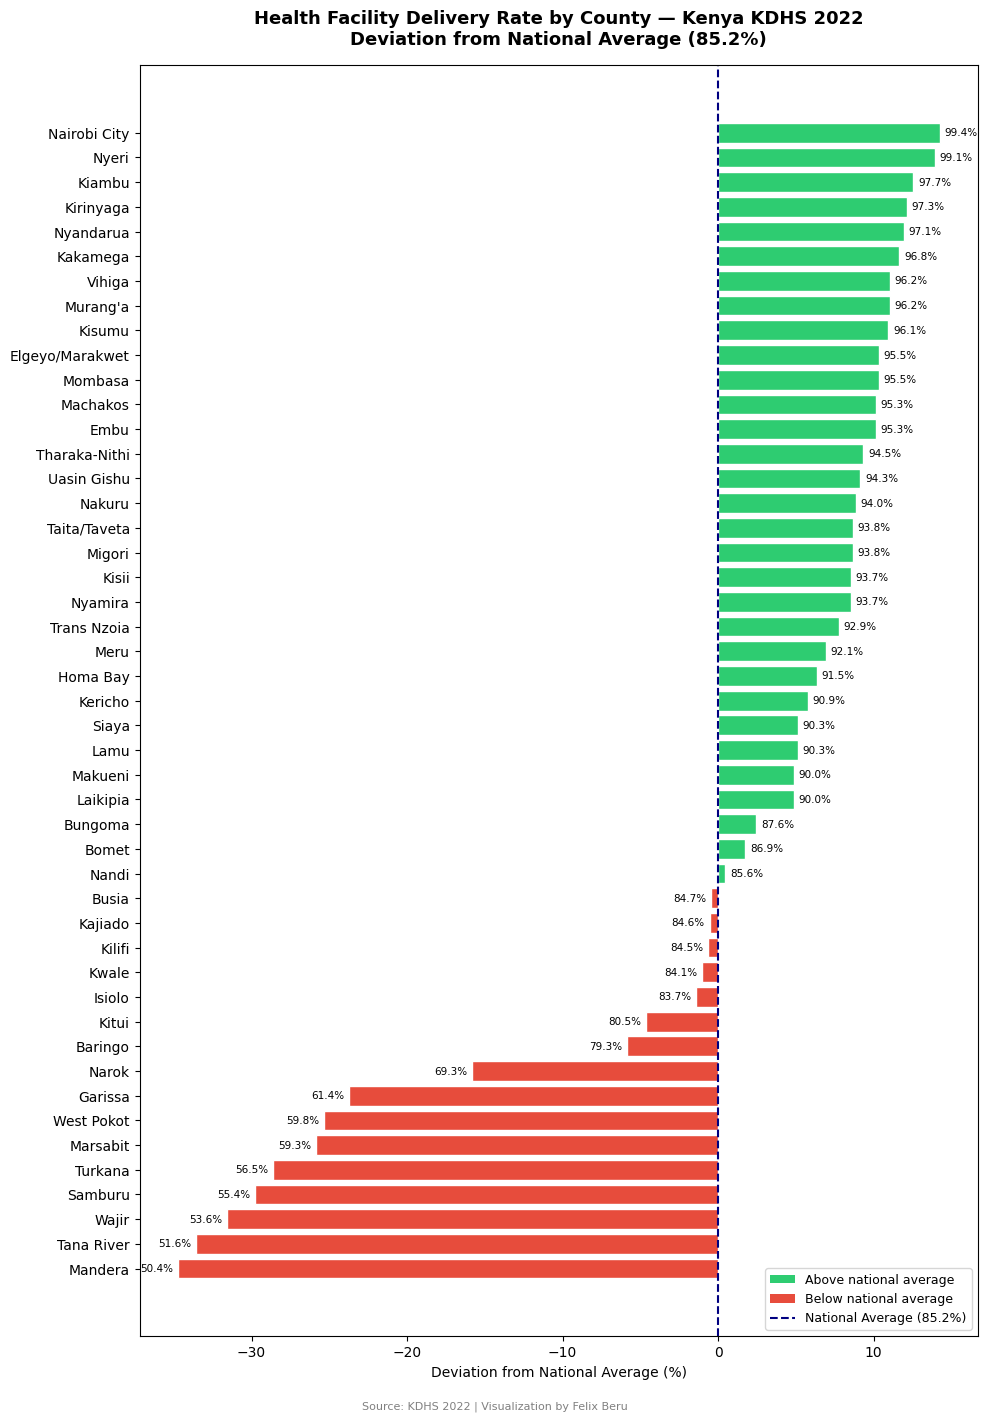

National Average: 85.2%
Below average counties: 16
Above average counties: 31


In [25]:
national_avg_del = df_del['Percentage_delivered_in_health_facility'].mean()
df_del['deviation'] = df_del['Percentage_delivered_in_health_facility'] - national_avg_del
df_del_sorted = df_del.sort_values('deviation', ascending=True)

colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in df_del_sorted['deviation']]

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(df_del_sorted['County'], df_del_sorted['deviation'],
        color=colors, edgecolor='white')

for i, (dev, pct) in enumerate(zip(df_del_sorted['deviation'],
        df_del_sorted['Percentage_delivered_in_health_facility'])):
    x_pos = dev + 0.3 if dev >= 0 else dev - 0.3
    ha = 'left' if dev >= 0 else 'right'
    ax.text(x_pos, i, f'{pct:.1f}%', va='center', fontsize=7.5, ha=ha)

ax.axvline(x=0, color='navy', linewidth=1.5, linestyle='--')

legend_elements = [
    mpatches.Patch(facecolor='#2ecc71', label='Above national average'),
    mpatches.Patch(facecolor='#e74c3c', label='Below national average'),
    plt.Line2D([0], [0], color='navy', linestyle='--',
               label=f'National Average ({national_avg_del:.1f}%)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_title('Health Facility Delivery Rate by County — Kenya KDHS 2022\n'
             'Deviation from National Average (85.2%)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Deviation from National Average (%)', fontsize=10)
fig.text(0.5, -0.01,
         'Source: KDHS 2022 | Visualization by Felix Beru',
         ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('/content/kenya_facility_delivery.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"National Average: {national_avg_del:.1f}%")
print(f"Below average counties: {len(df_del[df_del['deviation'] < 0])}")
print(f"Above average counties: {len(df_del[df_del['deviation'] > 0])}")

### Project 4 — Findings
- **National Average:** 85.2% — roughly 1 in 7 women delivers outside
  a health facility
- **16 out of 47 counties** fall below the national average
- **Largest gaps:** Mandera, Tana River and Wajir
- **Highest rates:** Nairobi City (99.4%), Nyeri (99.1%), Kiambu (97.7%)
- Tana River emerges as a new concern — remoteness and infrastructure
  driving home deliveries


## Series Conclusion — The Geography of Maternal Health Inequality in Kenya

### The Recurring Crisis Counties
Across all four projects, the same counties appear repeatedly at the bottom:

| County | ANC Coverage | ANC Quality | Under-5 Mortality | Facility Delivery |
|---|---|---|---|---|
| Mandera | 🔴 Bottom 3 | 🔴 Bottom 3 | 🔴 High | 🔴 Lowest |
| Wajir | 🔴 Bottom 3 | 🔴 Bottom 3 | 🔴 High | 🔴 Bottom 3 |
| Garissa | 🔴 Bottom 3 | 🔴 Bottom 3 | 🔴 High | 🔴 Bottom 3 |

### Key Insight
> Kenya's challenge is not coverage — it is equity. Where you are born
in Kenya determines whether your mother had skilled care, whether she
delivered safely, and whether you survived your first five years of life.

### Recommendations
1. Targeted investment in Mandera, Wajir and Garissa across all indicators
2. Quality over quantity — ANC attendance numbers are misleading without
   measuring timeliness and frequency
3. Tana River requires urgent attention as an emerging concern
4. Nyanza region needs disease-specific intervention addressing malaria
   and HIV driving under-5 mortality

---
**Felix Beru** | Data Analyst | Nairobi, Kenya  
[LinkedIn](http://www.linkedin.com/in/felix-beru-04b905280) |
[GitHub](https://github.com/FelixBeruTheAnalyst)